## Imports

In [1]:
import json
import sys
from ast import literal_eval

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

sys.path.append('..')
from const import *

## Support Functions

In [2]:
def compute_bins2(arr, arr2, breaks):
    densities = []
    bins = []
    for i in range(len(breaks)):
        temp = []
        for j, value in enumerate(arr):
            if i == 0:
                if value <= breaks[i]:
                    temp.append(arr2[j])
            else:
                if (value <= breaks[i]) & (value > breaks[i-1]):
                    temp.append(arr2[j])
        if temp:
            densities.append(len(temp)/len(repo_names))
            bins.append(temp)
    return breaks, bins, densities

## Overall Statistic

In [3]:
# load pull request data that contain vulnerabilities
pr_vuln = pd.read_csv(CSV_DATA['pr_vulnerabilities'], index_col=False)
pr_vuln['severities'] = pr_vuln['severities'].apply(literal_eval)

rejected_prs = sum(pr_vuln['state'] == 'CLOSED')
merged_prs = sum(pr_vuln['state'] == 'MERGED')
num_projects = len(pr_vuln.groupby('repository').count())

print('Pull request statistics')
print('total: {}'.format(len(pr_vuln.index)))
print('')
print('projects: {}'.format(num_projects))
print('')
print('open: '+str(sum(pr_vuln['state'] == 'OPEN'))+' ('+str((sum(pr_vuln['state'] == 'OPEN')/len(pr_vuln))*100)+')')
print('closed: '+str(sum(pr_vuln['state'] == 'CLOSED'))+' ('+str((sum(pr_vuln['state'] == 'CLOSED')/len(pr_vuln))*100)+')')
print('')
print('rejected: '+str(rejected_prs)+' ('+str(rejected_prs/sum(pr_vuln['state'] != 'OPEN')*100)+')')
print('merged: '+str(merged_prs)+' ('+str(merged_prs/sum(pr_vuln['state'] != 'OPEN')*100)+')')


Pull request statistics
total: 4416

projects: 978

open: 221 (5.004528985507246)
closed: 1804 (40.85144927536232)

rejected: 1804 (43.00357568533969)
merged: 2391 (56.99642431466031)


## Merge Rate Analysis

In [4]:
# load the names (GitHub slugs) of the selected repositories
repo_names = [
    'b2wads/grimorio-ui',
    'idena-network/idena-desktop',
    'rand256/valetudo',
    'vpython/glowscript',
    'grommet/grommet-designer',
    'omni/tokenbridge',
    'wordproof/wordproof-timestamp',
    'JuanIrache/gopro-telemetry',
    'linode/developers',
    'mobxjs/mst-gql'
]

In [5]:
projects_with_closed = []
merged = []
total = []
ratio = []
for repo_name in repo_names:
    # if repo_name not in pr_vuln.repository.unique().tolist():
    #     continue
    with open(os.path.join(JSON_DATA['security_updates_combined'], repo_name.replace('/', '@') + '.json'), 'r', encoding='utf-8') as json_file:
        prs = json.load(json_file)
        closed_prs = 0
        open_prs = 0
        merged_prs = 0
        for pr in prs:
            if pr['state'] == 'CLOSED':
                closed_prs += 1
            elif pr['state'] == 'OPEN':
                open_prs += 1
            elif pr['state'] == 'MERGED':
                merged_prs += 1
        if closed_prs + merged_prs:
            projects_with_closed.append(repo_name)
            merged.append(merged_prs)
            total.append(merged_prs + closed_prs)
            ratio.append(merged_prs/(merged_prs + closed_prs))

/var/folders/sg/t5yzf_q15rv0hp8hffg3ztrm0000gn/T/ipykernel_7786/1600274985.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(total, bins = 67, color="dodgerblue", fit=norm, kde=False, norm_hist=True)


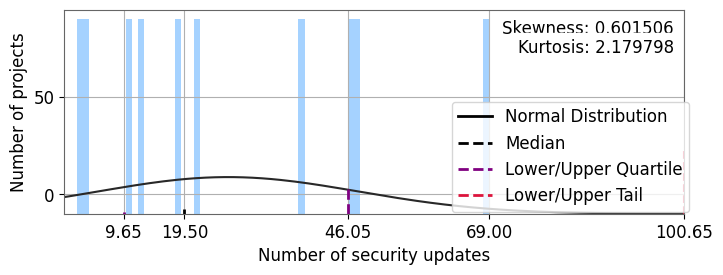

In [6]:
from scipy.stats import norm
from matplotlib.lines import Line2D

plt.rcParams["figure.figsize"] = (8,3)
plt.rcParams.update({'font.size':12})

ax = sns.distplot(total, bins = 67, color="dodgerblue", fit=norm, kde=False, norm_hist=True)
ax.text(x=0.983, y=0.95, transform=ax.transAxes, s="Skewness: %f" % stats.skew(total),
        fontsize=12, verticalalignment='top', horizontalalignment='right',
        backgroundcolor='white', color='black')
ax.text(x=0.983, y=0.86, transform=ax.transAxes, s="Kurtosis: %f" % stats.kurtosis(total, fisher=False),
        fontsize=12, verticalalignment='top', horizontalalignment='right',
        backgroundcolor='white', color='black')
ax.set_xlim([0,67])
ax.set_yticks([0.01, 0.06, 0.11, 0.16, 0.21, 0.26])
ax.set_yticklabels([0, 50, 100, 150, 200, 250])
quantiles = stats.mstats.mquantiles(total)
ax.set_ylabel('Number of projects')
ax.set_xlabel('Number of security updates')
ax.vlines(quantiles[1], 0, ax.lines[0].get_ydata()[int(quantiles[1])+12], color='black', ls='--',linewidth=2.0)
ax.vlines(quantiles[0], 0, ax.lines[0].get_ydata()[int(quantiles[0])+9], color='purple', ls='--',linewidth=2.0)
ax.vlines(quantiles[2], 0, ax.lines[0].get_ydata()[int(quantiles[2])+17], color='purple', ls='--',linewidth=2.0)
ax.vlines(quantiles[2] + 1.5*(quantiles[2]-quantiles[0]), 0, 0.033, color='crimson', ls='--')
ax.set_xticks([quantiles[0], quantiles[1], quantiles[2], quantiles[2] + 1.5*(quantiles[2]-quantiles[0]), max(total)])
custom_lines = [Line2D([0], [0], color='black', lw=2),
                Line2D([0], [0], color='black', ls='--', lw=2),
                Line2D([0], [0], color='purple', ls='--', lw=2),
                Line2D([0], [0], color='crimson', ls='--', lw=2)]
lgd = ax.legend(custom_lines, ['Normal Distribution', 'Median', 'Lower/Upper Quartile', 'Lower/Upper Tail'],
                bbox_to_anchor=(0.625, 0.55), loc='upper left', borderaxespad=0.)

ax.grid(None)
ax.spines['bottom'].set_color('0.4')
ax.spines['top'].set_color('0.4')
ax.spines['right'].set_color('0.4')
ax.spines['left'].set_color('0.4')

plt.subplots_adjust(bottom=0.2)

plt.savefig('RQ1-distribution.png', dpi=600, bbox_extra_artists=(lgd,), bbox_inches='tight')

In [7]:
breaks, bins, densities = compute_bins2(total, ratio, [2, 4, 10, 67])
plt.rcParams["figure.figsize"] = (20,5)
number_of_prs = []
merge_rates = []
for i, value in enumerate(breaks):
    if i == 0:
        for j in bins[i]:
            number_of_prs.append('[1,' + str(int(value)) + ']')
            merge_rates.append(j)
    else:
        if value - breaks[i-1] > 1:
            for j in bins[i]:
                number_of_prs.append('[' + str(int(breaks[i-1]) + 1) + ',' + str(int(value)) + ']')
                merge_rates.append(j)
        else:
            for j in bins[i]:
                number_of_prs.append(str(int(value)))
                merge_rates.append(j)
df = pd.DataFrame({'#_security_updates': number_of_prs, 'merge_ratio': merge_rates})
df.head()

,#_security_updates,merge_ratio
0,"[1,2]",0.000000
1,"[3,4]",0.333333
2,"[5,10]",0.200000
3,"[11,67]",0.447368
4,"[11,67]",0.521739


In [8]:
df2 = df.copy()
df2['merge_ratio'] = df2['merge_ratio']*100
groupedstats= df.groupby('#_security_updates').describe().reset_index().round(2)
groupedstats

#_security_updates merge_ratio                                         
                           count  mean  std   min   25%   50%   75%   max
0              [1,2]         1.0  0.00  NaN  0.00  0.00  0.00  0.00  0.00
1            [11,67]         6.0  0.41  0.3  0.06  0.17  0.48  0.52  0.85
2              [3,4]         1.0  0.33  NaN  0.33  0.33  0.33  0.33  0.33
3             [5,10]         1.0  0.20  NaN  0.20  0.20  0.20  0.20  0.20

In [9]:
#Total statistics
df2['merge_ratio'].describe().reset_index().round(2)

,index,merge_ratio
0,count,9.00
1,mean,33.51
2,std,27.87
3,min,0.00
4,25%,8.33
5,50%,33.33
6,75%,52.17
7,max,85.11


## Statistical Analysis

In [10]:
from scipy.stats import mannwhitneyu

df = df.rename(index=str,columns={'#_security_updates':'group'})

pvalues = []


categories = df.group.unique()

for i in range(0,len(categories)):
    for j in range(i,len(categories)):
        if i==j:
            continue
        
        group1 = categories[i]
        group2 = categories[j]
        stat, p = mannwhitneyu(df[df['group']==group1].merge_ratio.values.tolist(), 
                               df[df['group']==group2].merge_ratio.values.tolist())
        
        pvalues.append({
    'group1':group1,
    'group2':group2,
    'pvalue':p
})

pvalues = pd.DataFrame(pvalues)

In [11]:
#Bonferroni correction for multiple comparisons
import statsmodels.stats.multitest as smt

bonfresults = smt.multipletests(
            pvalues.pvalue.values.tolist(),
            alpha=0.05,
            method='bonferroni')

pvalues['corrected_pvalue'] = bonfresults[1]

newthres = bonfresults[3]

pvalues['rejectH0'] = pvalues.apply(lambda x: True if x['corrected_pvalue']<newthres else False , axis=1)
pvalues

,group1,group2,pvalue,corrected_pvalue,rejectH0
0,"[1,2]","[3,4]",1.000000,1.0,False
1,"[1,2]","[5,10]",1.000000,1.0,False
2,"[1,2]","[11,67]",0.285714,1.0,False
3,"[3,4]","[5,10]",1.000000,1.0,False
4,"[3,4]","[11,67]",0.857143,1.0,False
5,"[5,10]","[11,67]",0.857143,1.0,False


In [12]:
repo_popularity = pd.read_csv(CSV_DATA['repo_popularity'])
spearman = repo_popularity[['ratio', 'stars', 'forks']].corr(method="spearman")

print("(spearman) stars: %f, forks: %f" % (spearman['ratio']['stars'], spearman['ratio']['forks']))

(spearman) stars: 0.163205, forks: 0.159600


In [ ]:
##per-Repo Before/After Comparison

#"before" = original data only (pre May 2020)
#"after" = combined data (pre + post May 2020)

before_total = []
before_merged_list = []
before_ratio = []
before_group = []
after_total = []
after_merged_list = []
after_ratio_list = []
after_group = []

for repo_name in repo_names:

    # --- BEFORE ---
    filepath_before = os.path.join(JSON_DATA['security_updates'], repo_name.replace('/', '@') + '.json')
    if os.path.exists(filepath_before):
        with open(filepath_before, 'r', encoding='utf-8') as json_file:
            prs = json.load(json_file)
        closed_count = 0
        merged_count = 0
        for pr in prs:
            if pr['state'] == 'CLOSED':
                closed_count += 1
            elif pr['state'] == 'MERGED':
                merged_count += 1
        t = closed_count + merged_count
        r = merged_count / t if t > 0 else 0
    else:
        t = 0
        merged_count = 0
        r = 0

    before_total.append(t)
    before_merged_list.append(merged_count)
    before_ratio.append(round(r * 100, 2))

    if t == 0:
        before_group.append('N/A')
    elif t <= 2:
        before_group.append('Very low [1,2]')
    elif t <= 4:
        before_group.append('Low [3,4]')
    elif t <= 10:
        before_group.append('High [5,10]')
    else:
        before_group.append('Very high [11,67]')

    # --- AFTER ---
    filepath_after = os.path.join(JSON_DATA['security_updates_combined'], repo_name.replace('/', '@') + '.json')
    if os.path.exists(filepath_after):
        with open(filepath_after, 'r', encoding='utf-8') as json_file:
            prs = json.load(json_file)
        closed_count = 0
        merged_count = 0
        for pr in prs:
            if pr['state'] == 'CLOSED':
                closed_count += 1
            elif pr['state'] == 'MERGED':
                merged_count += 1
        t = closed_count + merged_count
        r = merged_count / t if t > 0 else 0
    else:
        t = 0
        merged_count = 0
        r = 0

    after_total.append(t)
    after_merged_list.append(merged_count)
    after_ratio_list.append(round(r * 100, 2))

    if t == 0:
        after_group.append('N/A')
    elif t <= 2:
        after_group.append('Very low [1,2]')
    elif t <= 4:
        after_group.append('Low [3,4]')
    elif t <= 10:
        after_group.append('High [5,10]')
    else:
        after_group.append('Very high [11,67]')

comparison_df = pd.DataFrame({
    'repo': repo_names,
    'before_total_prs': before_total,
    'before_merge_ratio (%)': before_ratio,
    'before_group': before_group,
    'after_total_prs': after_total,
    'after_merge_ratio (%)': after_ratio_list,
    'after_group': after_group,
})

comparison_df['group_changed'] = comparison_df['before_group'] != comparison_df['after_group']
comparison_df['ratio_delta (%)'] = comparison_df['after_merge_ratio (%)'] - comparison_df['before_merge_ratio (%)']

comparison_df

,repo,before_total_prs,before_merge_ratio (%),before_group,after_total_prs,after_merge_ratio (%),after_group,group_changed,ratio_delta (%)
0,b2wads/grimorio-ui,2,50.00,"Very low [1,2]",3,33.33,"Low [3,4]",True,-16.67
1,idena-network/idena-desktop,6,50.00,"High [5,10]",38,44.74,"Very high [11,67]",True,-5.26
2,rand256/valetudo,1,0.00,"Very low [1,2]",2,0.00,"Very low [1,2]",False,0.00
3,vpython/glowscript,1,0.00,"Very low [1,2]",46,52.17,"Very high [11,67]",True,52.17
4,grommet/grommet-designer,1,0.00,"Very low [1,2]",18,5.56,"Very high [11,67]",True,5.56
5,omni/tokenbridge,0,0.00,N/A,10,20.00,"High [5,10]",True,20.00
6,wordproof/wordproof-timestamp,2,0.00,"Very low [1,2]",21,52.38,"Very high [11,67]",True,52.38
7,JuanIrache/gopro-telemetry,1,100.00,"Very low [1,2]",12,8.33,"Very high [11,67]",True,-91.67
8,linode/developers,1,0.00,"Very low [1,2]",47,85.11,"Very high [11,67]",True,85.11
9,mobxjs/mst-gql,31,51.61,"Very high [11,67]",69,47.83,"Very high [11,67]",False,-3.78
